# Phase 2: The Baseline Classifier (Naive Bayes)

Initial classifier using **Multinomial Naive Bayes**.

###  Why Naive Bayes?
1.  **Transparency (The White Box)**: This model is based on pure probability (counting word frequencies). We can see exactly which words define Fake vs Real news.
2.  **Benchmark Strategy**: Before trying complex Neural Networks, we must set a benchmark. If a simple model performs exceptionally well, we save the company (or instructors) time and resources.

3.  **Speed**: It is lightning-fast, allowing us to iterate quickly even on large datasets.

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import nltk
import re
import string
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Colab Integration: Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/Project 2/project-nlp-challenge'
    print("✅ Running in Colab. Google Drive mounted.")
except ImportError:
    BASE_PATH = '.'
    print("💻 Running Locally.")

# NLTK Downloads for ephemeral environments
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Ensure directories exist
os.makedirs(os.path.join(BASE_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'dataset'), exist_ok=True)


Mounted at /content/drive
✅ Running in Colab. Google Drive mounted.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
import os

dataset_path = os.path.join(BASE_PATH, 'dataset')
print(f"Contents of {dataset_path}:")
if os.path.exists(dataset_path) and os.path.isdir(dataset_path):
    for item in os.listdir(dataset_path):
        print(item)
else:
    print(f"Directory does not exist or is not a directory: {dataset_path}")

Contents of /content/drive/MyDrive/Project 2/project-nlp-challenge/dataset:
data.csv
validation_data.csv
.DS_Store
train.csv
test.csv
cleaned_data.csv


## 1. Data Ingestion (The Sliced Ingredients)
We load our stratified Train and Test sets created in Phase 1.

In [4]:
train_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/train.csv'))
test_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/test.csv'))

# Load the fitted vectorizer
tfidf = joblib.load(os.path.join(BASE_PATH, 'models/vectorizer.joblib'))

print(f"Data Loaded. Train: {train_df.shape}, Test: {test_df.shape}")

Data Loaded. Train: (31908, 7), Test: (7978, 7)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Transformation
We convert the cleaned text into their TF-IDF numerical vectors.

In [5]:
X_train = tfidf.transform(train_df['cleaned_text'].astype(str))
y_train = train_df['label']

X_test = tfidf.transform(test_df['cleaned_text'].astype(str))
y_test = test_df['label']

print("Vectors Generated.")

Vectors Generated.


## 3. Training: The Multinomial Naive Bayes
We train the model on our training data.

In [6]:
# 1. Instantiate and Train Naive Bayes (Standard)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
joblib.dump(nb_model, os.path.join(BASE_PATH, 'models/nb_tfidf_classifier.joblib'))

# 2. Train Logistic Regression (For Comparison Phase)
lr_tfidf_model = LogisticRegression(max_iter=1000)
lr_tfidf_model.fit(X_train, y_train)
joblib.dump(lr_tfidf_model, os.path.join(BASE_PATH, 'models/lr_tfidf_classifier.joblib'))
print("Both Models (NB & LR) Trained and Persistent.")


Both Models (NB & LR) Trained and Persistent.


### Persistence & Comparison Training
We save our model and train a secondary Logistic Regression to compare in the next phase.


## 4. Evaluation & Visualization
How well does our model perform on the test set?


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      3989
           1       0.95      0.94      0.94      3989

    accuracy                           0.94      7978
   macro avg       0.94      0.94      0.94      7978
weighted avg       0.94      0.94      0.94      7978



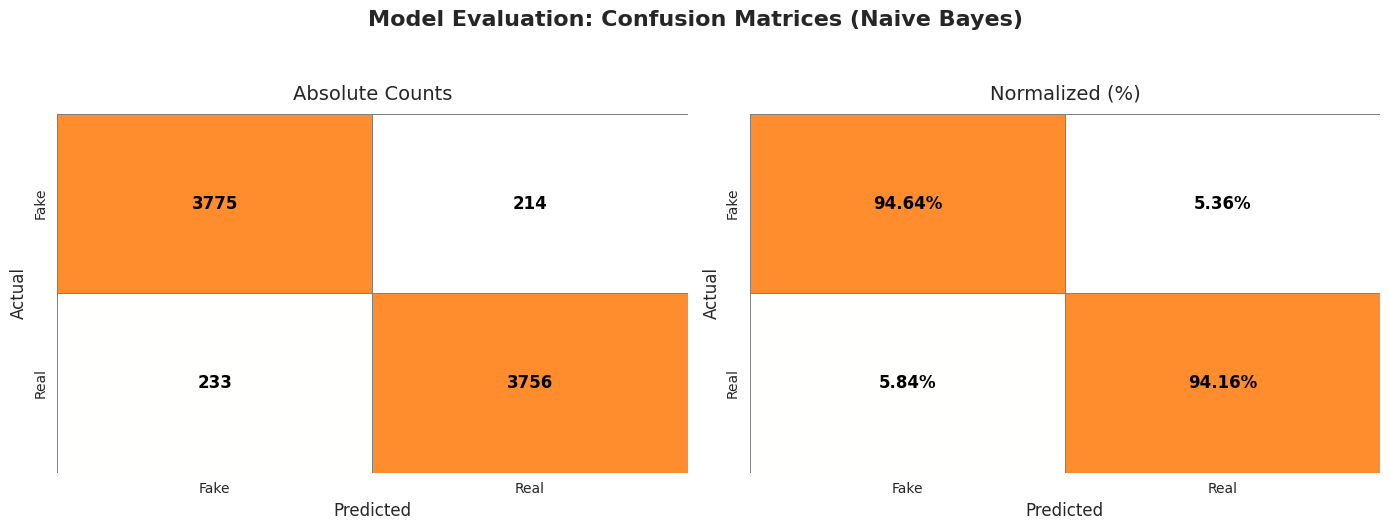



🎯 Keywords to REAL NEWS:
['washington reuters' 'reuters us' 'reuters' 'myanmar' 'catalan'
 'rohingya' 'catalonia' 'reuters president' 'moscow reuters'
 'london reuters']

🚩 Keywords to FAKE NEWS:
['image via' 'screen capture' '2017realdonaldtrump' 'getty' 'gop'
 'getty images' 'featured image' 'hilarious' 'screenshot' 'video screen']


In [7]:
y_pred = nb_model.predict(X_test)
print()
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- Brand Visual Style Setup ---
import matplotlib.colors as mcolors
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.rcParams['font.family'] = 'sans-serif'
brand_colors = ["#FF8D2D", "#00B5AD"] # Orange for Fake News, Cyan for Real News

# Create a custom colormap fading from white to the brand's ORANGE color
brand_cmap = mcolors.LinearSegmentedColormap.from_list("brand_cmap", ["white", brand_colors[0]])

# 1. Confusion Matrix
# 1.1 Calculate both matrices (Counts and Percentages)
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# 1.2 Create the figure with 1 row and 2 columns side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Absolute Confusion Matrix (Left) ---
sns.heatmap(cm, annot=True, fmt='d', cmap=brand_cmap, ax=ax[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            cbar=False, linewidths=0.5, linecolor='gray',
            annot_kws={"color": "black", "weight": "bold", "size": 12}) # Texto negro y negrita
ax[0].set_title('Absolute Counts', fontsize=14, pad=10)
ax[0].set_xlabel('Predicted', fontsize=12)
ax[0].set_ylabel('Actual', fontsize=12)

# --- PLOT 2: Normalized Confusion Matrix (Right) ---
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap=brand_cmap, ax=ax[1],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            cbar=False, linewidths=0.5, linecolor='gray',
            annot_kws={"color": "black", "weight": "bold", "size": 12}) # Texto negro y negrita
ax[1].set_title('Normalized (%)', fontsize=14, pad=10)
ax[1].set_xlabel('Predicted', fontsize=12)
ax[1].set_ylabel('Actual', fontsize=12)

# Add a main title for the entire figure
plt.suptitle('Model Evaluation: Confusion Matrices (Naive Bayes)', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

print()

# 2. Identify the words that best define each class (Naive Bayes)
feature_names = tfidf.get_feature_names_out()
probs = nb_model.feature_log_prob_
words_df = pd.DataFrame({
    'word': feature_names,
    'fake_weight': probs[0],
    'real_weight': probs[1]
})

words_df['diff'] = words_df['real_weight'] - words_df['fake_weight']
print("\n🎯 Keywords to REAL NEWS:")
print(words_df.sort_values(by='diff', ascending=False).head(10)['word'].values)
print("\n🚩 Keywords to FAKE NEWS:")
print(words_df.sort_values(by='diff', ascending=True).head(10)['word'].values)

We see that the word ‘reuters’ is a very strong predictor of real news. This tells us that the model performs very well on this dataset, but if we feed it a real news article that is NOT from Reuters, it might struggle a bit more. This is a bias in the dataset that we've identified thanks to the transparency of the Naive Bayes model.

## 5. Final Deliverable: Validation Predictions
we must predict labels for `validation_data.csv` and ensure the output file has **NO extra columns** and maintains the exact original format.

In [9]:
val_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/validation_data.csv'))

# 1. Applying exactly the same fusion and cleaning logic
# Note: In a production setting, we would import the clean_text function from a module.
def clean_text(text):
    import re, string
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords

    if pd.isna(text): return ""
    text = text.lower()
    pattern = re.compile('[%s]' % re.escape(string.punctuation))
    text = pattern.sub('', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(filtered_tokens)

print("Scrubbing validation data...")
val_full_text = (val_df['title'] + " " + val_df['text']).apply(clean_text)

# 2. Vectorization
X_val = tfidf.transform(val_full_text)

# 3. Prediction
val_df['label'] = nb_model.predict(X_val)

# 4. Final Guard: Export strictly following original format
# Columns required: original columns only, no 'full_text' or 'cleaned_text' helper columns
final_output_path = os.path.join(BASE_PATH, 'dataset/validation_results.csv')
val_df.to_csv(final_output_path, index=False)

print(f"Validation predictions saved to: {final_output_path}")

Scrubbing validation data...
Validation predictions saved to: /content/drive/MyDrive/Project 2/project-nlp-challenge/dataset/validation_results.csv
